# Teil 4: Evaluation

In diesem Notebook bewerte ich das Modell genauer. Ich verwende wieder den gleichen Datensatz und die gleiche einfache Vorbereitung wie im Modell-Notebook.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


## Daten vorbereiten

Die Vorbereitung ist gleich wie vorher: unnötige Spalten entfernen und Textspalten in Zahlen umwandeln.


In [2]:
df = pd.read_csv('churn_modelling.csv')

df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df_model = pd.get_dummies(df_model, columns=['Geography', 'Gender'], drop_first=True)

y = df_model['Exited']
X = df_model.drop(columns=['Exited'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## Wichtige Felder

Beim Random Forest kann man `feature_importances_` anschauen. Das zeigt, welche Felder für das Modell am wichtigsten waren.


In [3]:
wichtigkeiten = pd.DataFrame({
    'Feld': X.columns,
    'Wichtigkeit': model.feature_importances_
}).sort_values('Wichtigkeit', ascending=False)

wichtigkeiten.head(10)


,Feld,Wichtigkeit
1,Age,0.236922
7,EstimatedSalary,0.147558
0,CreditScore,0.143338
3,Balance,0.141612
4,NumOfProducts,0.131486
2,Tenure,0.082080
6,IsActiveMember,0.040725
8,Geography_Germany,0.026190
5,HasCrCard,0.018454
10,Gender_Male,0.018421


## Kurze Interpretation der wichtigen Felder

In meinem Lauf sind vor allem `Age`, `EstimatedSalary`, `CreditScore`, `Balance` und `NumOfProducts` weit oben. Das bedeutet nicht automatisch, dass diese Felder der echte Grund für eine Kündigung sind. Es zeigt nur, dass das Modell diese Spalten stark für seine Entscheidungen benutzt.

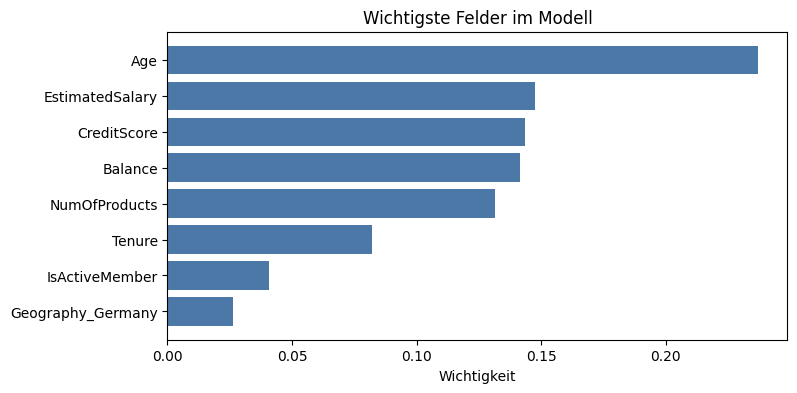

In [4]:
top = wichtigkeiten.head(8)

plt.figure(figsize=(8, 4))
plt.barh(top['Feld'], top['Wichtigkeit'], color='#4c78a8')
plt.title('Wichtigste Felder im Modell')
plt.xlabel('Wichtigkeit')
plt.gca().invert_yaxis()
plt.show()


## Messwerte

Ich berechne Accuracy, Precision, Recall und F1-Score. So sieht man besser, wie gut das Modell wirklich ist.


In [5]:
metriken = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall / Sensitivität', 'F1-Score'],
    'Wert': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

metriken['Wert'] = metriken['Wert'].round(4)
metriken


,Metrik,Wert
0,Accuracy,0.8665
1,Precision,0.7582
2,Recall / Sensitivität,0.4707
3,F1-Score,0.5808


## Bedingung für die Wahrheitsmatrix

Bei diesem Datensatz ist die Bedingung einfach: `Exited = 1` bedeutet, dass ein Kunde gekündigt hat. Wenn das Modell `1` vorhersagt, zählt das als "kündigt". Wenn es `0` vorhersagt, zählt das als "bleibt".

## Confusion Matrix

Die Confusion Matrix zeigt, welche Fälle richtig und falsch vorhergesagt wurden.


In [6]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Echt 0', 'Echt 1'],
    columns=['Vorhersage 0', 'Vorhersage 1']
)

cm_df


,Vorhersage 0,Vorhersage 1
Echt 0,1548,59
Echt 1,208,185


In [7]:
tn, fp, fn, tp = cm.ravel()

sensitivitaet = tp / (tp + fn)
spezifitaet = tn / (tn + fp)

print('Sensitivität / Recall:', round(sensitivitaet, 4))
print('Spezifizität:', round(spezifitaet, 4))


Sensitivität / Recall: 0.4707
Spezifizität: 0.9633


## Beurteilung

Das Modell funktioniert insgesamt recht gut, wenn man nur die Accuracy anschaut. Bei der Sensitivität sieht man aber, dass nicht alle kündigenden Kunden erkannt werden. Das ist wichtig, weil genau diese Kunden für eine Bank interessant wären. Die Spezifizität ist besser, weil die vielen bleibenden Kunden leichter richtig erkannt werden. Das Modell ist also brauchbar, aber nicht perfekt.


## Hypothesen

- Das Alter könnte wichtig sein, weil ältere und jüngere Kunden vielleicht verschieden reagieren.
- `Balance` und `NumOfProducts` könnten wichtig sein, weil sie zeigen, wie stark jemand die Bank nutzt.
- `IsActiveMember` könnte helfen, weil aktive Kunden eher bleiben könnten.
- Das Modell macht Fehler, weil Kundenverhalten nicht nur aus diesen Spalten erklärbar ist.
- Der Datensatz ist unausgeglichen, weil viel mehr Kunden nicht gekündigt haben als gekündigt haben.
